In [49]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    roc_curve
)

# Load signals.csv
df = pd.read_csv("signals.csv")

# Convert date and sort chronologically
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

In [50]:
signal_cols = [
    "1d_return",
    "5d_return",
    "20d_return",
    "percent_ma_gap",
    "sma_crossover",
    "20d_drawdown",
    "10d_volatility",
    "volatility_ratio",
    "volume_zscore",
    "rsi_14"
]

target = "target"

# Keep first 49 SMA crossover values as NaN
df.loc[:48, "sma_crossover"] = np.nan

# Keep last 5 target values as NaN
df.loc[df["future_5d_return"].isna(), "target"] = np.nan

# Create modeling dataset and remove rows with NaN values
model_df = df[["date"] + signal_cols + [target]].dropna(
    subset=signal_cols + [target]
).reset_index(drop=True)

print(model_df.shape)

(1201, 12)


In [51]:
initial_train_size = int(len(model_df) * 0.80)
block_size = 21

walk_forward_results = []

In [52]:
purge_gap = 5
walk_forward_results = []

for start in range(initial_train_size, len(model_df), block_size):

    end = min(start + block_size, len(model_df))

    # Keep a 5-day gap because the target looks 5 trading days ahead
    train_end = start - purge_gap

    train_data = model_df.iloc[:train_end].copy()
    test_data = model_df.iloc[start:end].copy()

    # Training data
    X_train = sm.add_constant(
        train_data[signal_cols],
        has_constant="add"
    )
    y_train = train_data[target]

    # Fit logistic regression
    model = sm.Logit(y_train, X_train).fit(disp=False)

    # Test data
    X_test = sm.add_constant(
        test_data[signal_cols],
        has_constant="add"
    )

    X_test = X_test[X_train.columns]

    # Generate probabilities
    predicted_prob = model.predict(X_test)

    # Majority-class benchmark based only on past training data
    majority_class = int(y_train.mode().iloc[0])

    block_results = pd.DataFrame({
        "date": test_data["date"].to_numpy(),
        "actual": test_data[target].to_numpy(),
        "predicted_prob": predicted_prob.to_numpy(),
        "baseline_pred": majority_class
    })

    walk_forward_results.append(block_results)

In [53]:
import os

walk_forward_df = pd.concat(
    walk_forward_results,
    ignore_index=True
)

walk_forward_df["predicted_class"] = (
    walk_forward_df["predicted_prob"] >= 0.5
).astype(int)

os.makedirs("../results", exist_ok=True)

walk_forward_df.to_csv(
    "../results/walk_forward_predictions.csv",
    index=False
)

print(walk_forward_df.head())
print("Number of walk-forward predictions:", len(walk_forward_df))

        date  actual  predicted_prob  baseline_pred  predicted_class
0 2025-08-05     1.0        0.588814              1                1
1 2025-08-06     1.0        0.572077              1                1
2 2025-08-07     1.0        0.565479              1                1
3 2025-08-08     1.0        0.561201              1                1
4 2025-08-11     1.0        0.595923              1                1
Number of walk-forward predictions: 241


In [54]:
y_true = walk_forward_df["actual"]
y_prob = walk_forward_df["predicted_prob"]
y_pred = walk_forward_df["predicted_class"]

# Model metrics
accuracy = accuracy_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
brier = brier_score_loss(y_true, y_prob)

# Majority-class benchmark
baseline_accuracy = accuracy_score(
    y_true,
    walk_forward_df["baseline_pred"]
)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
).ravel()

print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)
print("Brier Score:", brier)
print("Majority-Class Accuracy:", baseline_accuracy)

print("\nConfusion Matrix")
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

Accuracy: 0.5933609958506224
ROC-AUC: 0.41908091908091905
Brier Score: 0.2496145367151104
Majority-Class Accuracy: 0.5933609958506224

Confusion Matrix
True Negatives: 0
False Positives: 98
False Negatives: 0
True Positives: 143


In [55]:
metrics_df = pd.DataFrame({
    "metric": [
        "Accuracy",
        "ROC-AUC",
        "Brier Score",
        "Majority-Class Accuracy",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],
    "value": [
        accuracy,
        roc_auc,
        brier,
        baseline_accuracy,
        tn,
        fp,
        fn,
        tp
    ]
})

metrics_df.to_csv(
    "../results/validation_metrics.csv",
    index=False
)

print(metrics_df)

                    metric       value
0                 Accuracy    0.593361
1                  ROC-AUC    0.419081
2              Brier Score    0.249615
3  Majority-Class Accuracy    0.593361
4           True Negatives    0.000000
5          False Positives   98.000000
6          False Negatives    0.000000
7           True Positives  143.000000


In [56]:
from statsmodels.stats.power import GofChisquarePower

n_oos = len(y_true)
alpha = 0.05

p0 = baseline_accuracy
p1 = min(p0 + 0.05, 0.999)

effect_size = abs(p1 - p0) / np.sqrt(p0 * (1 - p0))

power_5pp = GofChisquarePower().power(
    effect_size=effect_size,
    nobs=n_oos,
    alpha=alpha,
    n_bins=2
)

effect_size_80 = GofChisquarePower().solve_power(
    effect_size=None,
    nobs=n_oos,
    alpha=alpha,
    power=0.80,
    n_bins=2
)

mde_80 = effect_size_80 * np.sqrt(p0 * (1 - p0))

print("Out-of-sample observations:", n_oos)
print("Power to detect +5 percentage points:", power_5pp)
print("Approx. improvement needed for 80% power:", mde_80)

Out-of-sample observations: 241
Power to detect +5 percentage points: 0.3522635565885243
Approx. improvement needed for 80% power: 0.08864593972824257


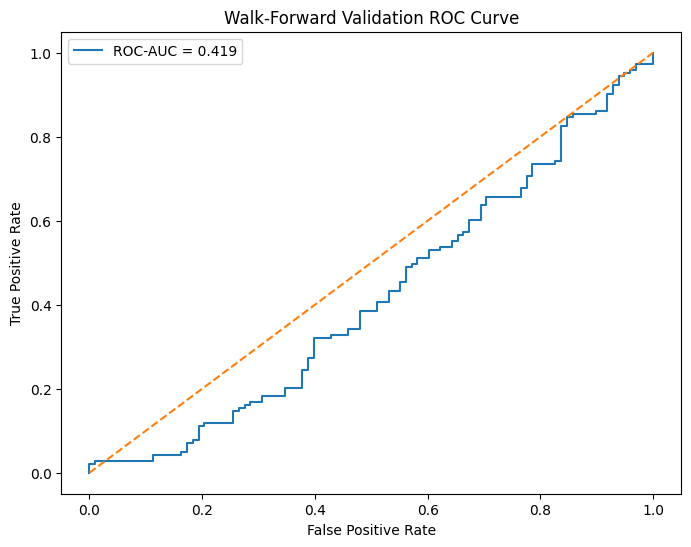

In [57]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Walk-Forward Validation ROC Curve")
plt.legend()

# Create the figures directory if it doesn't exist
figures_dir = "../figures"
os.makedirs(figures_dir, exist_ok=True)

plt.savefig(
    os.path.join(figures_dir, "roc_curve.png"),
    bbox_inches="tight"
)

plt.show()

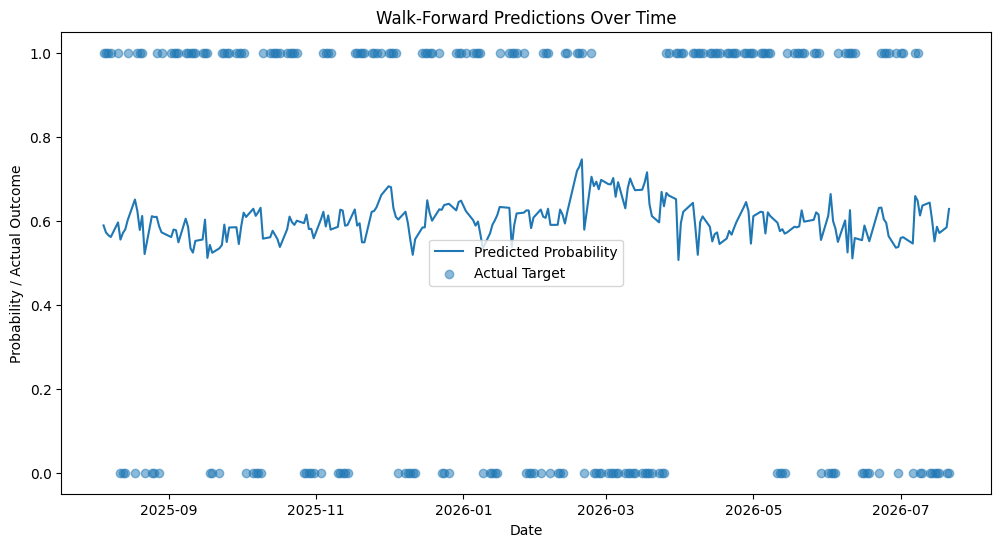

In [58]:
plt.figure(figsize=(12, 6))

plt.plot(
    walk_forward_df["date"],
    walk_forward_df["predicted_prob"],
    label="Predicted Probability"
)

plt.scatter(
    walk_forward_df["date"],
    walk_forward_df["actual"],
    alpha=0.5,
    label="Actual Target"
)

plt.xlabel("Date")
plt.ylabel("Probability / Actual Outcome")
plt.title("Walk-Forward Predictions Over Time")
plt.legend()

plt.savefig(
    "../figures/predictions_over_time.png",
    bbox_inches="tight"
)

plt.show()

In [59]:
os.makedirs("../docs", exist_ok=True)

if accuracy > baseline_accuracy and roc_auc > 0.5:
    conclusion = (
        "The model showed some evidence of outperforming "
        "the simple majority-class baseline."
    )
else:
    conclusion = (
        "The model did not outperform the simple majority-class baseline "
        "during walk-forward validation. Both achieved an accuracy of 59.34%. "
        "At the 0.50 classification threshold, the logistic regression predicted "
        "the positive class for every validation observation. The ROC-AUC of "
        "0.419 indicates that the predicted probabilities did not effectively "
        "distinguish between subsequent upward and downward SPY movements. "
        "Overall, the tested signals did not provide evidence of useful "
        "out-of-sample directional forecasting performance under this baseline model. "
    )

summary = f"""# Walk-Forward Validation Summary

## Method

The logistic regression model was evaluated using expanding-window
walk-forward validation.

An initial historical training period was used to fit the model.
The next approximately one-month block was then predicted.
After each prediction block, the training window expanded and the model
was refitted using the available historical observations.

A five-trading-day gap was maintained between the end of each training
window and the beginning of the next test block because the target
measures SPY's direction over the following five trading days.

## Results

- Accuracy: {accuracy:.4f}
- ROC-AUC: {roc_auc:.4f}
- Brier Score: {brier:.4f}
- Majority-Class Accuracy: {baseline_accuracy:.4f}

## Confusion Matrix

- True Negatives: {tn}
- False Positives: {fp}
- False Negatives: {fn}
- True Positives: {tp}

## Statistical Power — Supplementary

The validation contained {n_oos} out-of-sample predictions.

An approximate power analysis indicated {power_5pp:.1%} power to detect
a five-percentage-point improvement over the majority-class benchmark
at the 5% significance level.

Approximately an {mde_80:.1%} improvement over the baseline would be
needed to achieve 80% power under this approximation.

This analysis is supplementary and does not change the primary
walk-forward validation conclusion.

## Conclusion

{conclusion}

The results are reported as observed rather than optimizing the model
until it appears successful.
"""

with open("../docs/validation_summary.md", "w") as f:
    f.write(summary)

print(summary)

# Walk-Forward Validation Summary

## Method

The logistic regression model was evaluated using expanding-window
walk-forward validation.

An initial historical training period was used to fit the model.
The next approximately one-month block was then predicted.
After each prediction block, the training window expanded and the model
was refitted using the available historical observations.

A five-trading-day gap was maintained between the end of each training
window and the beginning of the next test block because the target
measures SPY's direction over the following five trading days.

## Results

- Accuracy: 0.5934
- ROC-AUC: 0.4191
- Brier Score: 0.2496
- Majority-Class Accuracy: 0.5934

## Confusion Matrix

- True Negatives: 0
- False Positives: 98
- False Negatives: 0
- True Positives: 143

## Statistical Power — Supplementary

The validation contained 241 out-of-sample predictions.

An approximate power analysis indicated 35.2% power to detect
a five-percentage-point improvemen